--- Task 1: Decision Tree Analysis ---


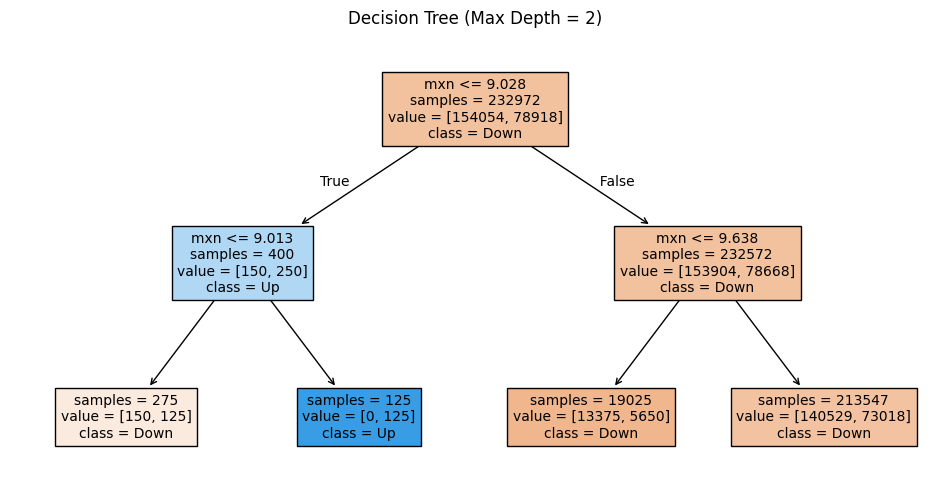

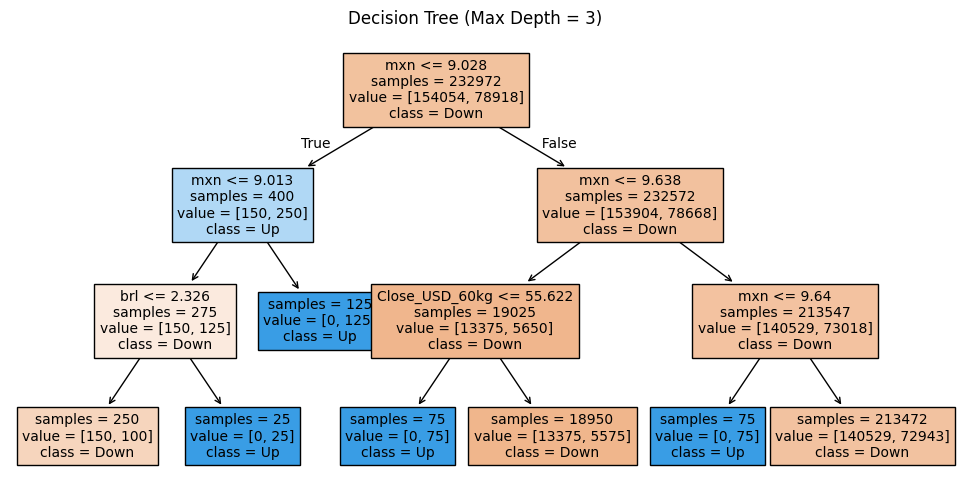

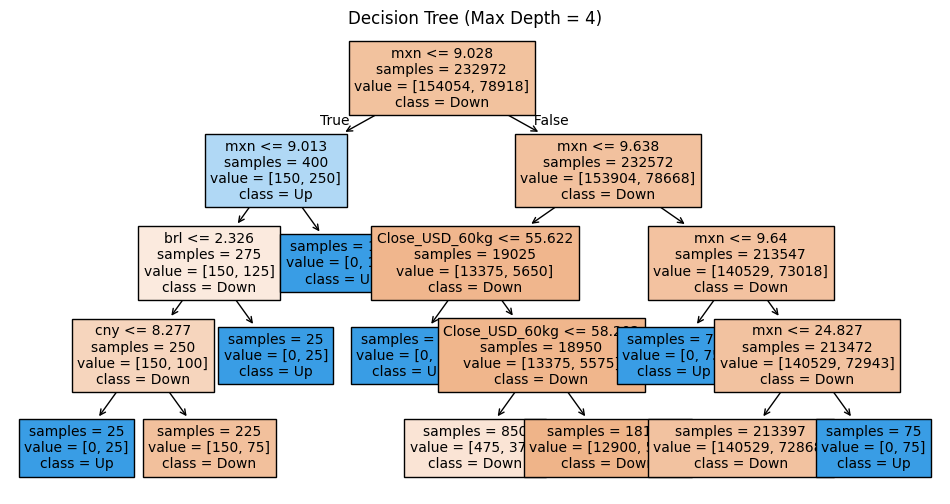

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
from scipy import stats

df = pd.read_csv('/content/Coffee_Data_Set.csv')
df['Date'] = pd.to_datetime(df['Date'])

daily_prices = df[['Date', 'Close_USD_60kg']].drop_duplicates().sort_values('Date')
daily_prices['Next_Day_Price'] = daily_prices['Close_USD_60kg'].shift(-1)
daily_prices['Target'] = (daily_prices['Next_Day_Price'] > daily_prices['Close_USD_60kg']).astype(int)

df = df.merge(daily_prices[['Date', 'Target']], on='Date', how='inner')

features = ['Temp_Max', 'Temp_Min', 'Humidity', 'Solar_Radiation',
            'Precipitation_mm', 'Close_USD_60kg', 'brl', 'cny', 'mxn']
df = df.dropna(subset=features)

X = df[features]
y = df['Target']

print("--- Task 1: Decision Tree Analysis ---")

depths = [2, 3, 4]
dts = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X, y)
    dts.append(clf)

    plt.figure(figsize=(12, 6))
    plot_tree(clf, feature_names=features, class_names=['Down', 'Up'],
              filled=True, fontsize=10, impurity=False)
    plt.title(f"Decision Tree (Max Depth = {d})")
    plt.show()



# Task 1


## Depth and Complexity

The depth and the complexity are directly related. As there is more depth to the tree, the amount of "decisions" exponentially increases. This increases the complexity of the model.

**Low Complexity/Low Depth**: This leads to a model with high bias but low variance. The tree only captures global trends but is unable to capture more complex signals. (Underfitting)

**High Complexity/High Depth:** This leads to model with low bias but high variance.  The tree captures complex trends well but can over generalize signals that only appear scarcely to all data. This leads to high variance, where the model overfits to the training data.

## Analysis of Visualization

**Depth 2:** The model simply splits the data by ```close price```, then by the ```mxn``` exchange rate. This behavior is expected as these values are the best indicators of the next day price.

**Depth 3/4+:** Something that I noticed that was not expected was the continued split by only ```mxn``` and ```close price```. This is explained by the way the CART algorithm chooses these based off the best information gain. The decision tree realized that the other features are not as important or correlated with the target variable.


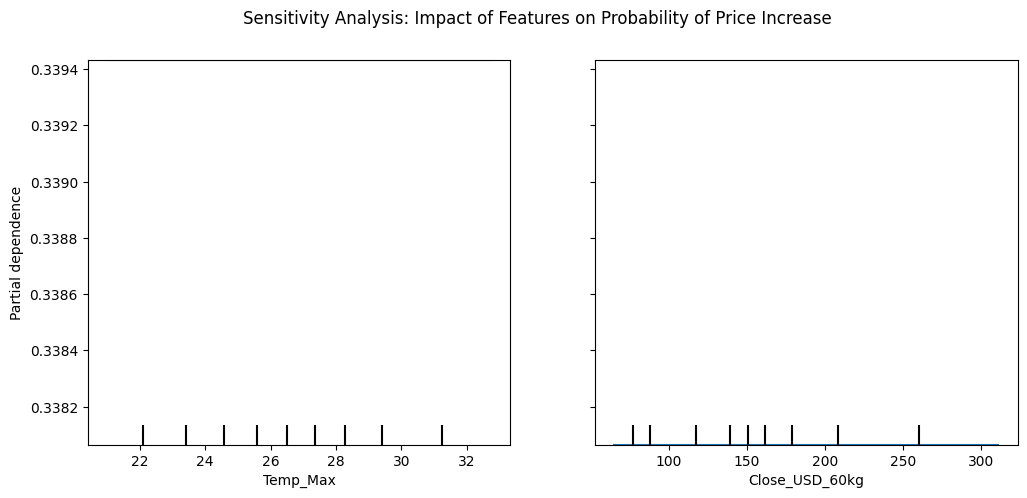

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(dts[-1], X, ['Temp_Max', 'Close_USD_60kg'], ax=ax)
plt.suptitle("Sensitivity Analysis: Impact of Features on Probability of Price Increase")
plt.show()


## Sensitivity Analysis

**Research:** Sensitivity analysis determines how target variables are affected based on changes in other input variables. In machine learning, techniques like Partial Dependence Plots (PDP) or Permutation Feature Importance are used.

**Citation:** Molnar, C. (2020). Interpretable Machine Learning.

https://christophm.github.io/interpretable-ml-book/pdp.html

**Impact:** In this model, the PDPs show that there is an expected value of 33.8% chance that the price goes up. The two features displayed, ```Temp_Max``` and ```Close_USD_60kg```, show that no matter the change in these input variables, the change is max 0.0002, or 0.02%, exemplifying that these variables provide no signal to whether the price goes up and down or not. (Low Sensitivity)

**Interpetation**: You might think that price should directly correlate with whether the price goes up or down the next day. But this graph does make sense, just knowing the price gives no information about whether it goes up or down. The ```Temp_Max``` plot just shows that this feature is not important for the prediction of the target variable.

In [12]:
print("\n--- Task 2: Ensemble Methods with Multiple Folds ---")

models = {
    'RandomForest (Bagging)': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    'GradientBoosting (Boosting)': GradientBoostingClassifier(n_estimators=50, max_depth=3, random_state=42)
}

fold_counts = [5, 10, 15]
metrics = ['precision', 'recall', 'f1']
cv_summary = []

for k in fold_counts:
    print(f"\nRunning Stratified {k}-Fold Cross-Validation...")
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for name, model in models.items():
        results = cross_validate(model, X, y, cv=skf, scoring=metrics, return_train_score=True)

        cv_summary.append({
            'Model': name,
            'Folds': k,
            'Precision': results['test_precision'].mean(),
            'Recall': results['test_recall'].mean(),
            'F1': results['test_f1'].mean(),
            'F1_Scores': results['test_f1'],
            'Train_Precision': results['train_precision'].mean(),
            'Train_Recall': results['train_recall'].mean(),
            'Train_F1': results['train_f1'].mean()
        })

# Display Results
summary_df = pd.DataFrame(cv_summary)
print("Train Results")
print(summary_df[['Model', 'Folds', 'Train_Precision', 'Train_Recall', 'Train_F1']])
print("Test Results")
print(summary_df[['Model', 'Folds', 'Precision', 'Recall', 'F1']])


--- Task 2: Ensemble Methods with Multiple Folds ---

Running Stratified 5-Fold Cross-Validation...

Running Stratified 10-Fold Cross-Validation...

Running Stratified 15-Fold Cross-Validation...
Train Results
                         Model  Folds  Train_Precision  Train_Recall  Train_F1
0       RandomForest (Bagging)      5         1.000000      0.032540  0.063019
1  GradientBoosting (Boosting)      5         0.985231      0.015510  0.030533
2       RandomForest (Bagging)     10         1.000000      0.033251  0.064357
3  GradientBoosting (Boosting)     10         0.985767      0.014845  0.029248
4       RandomForest (Bagging)     15         1.000000      0.032972  0.063828
5  GradientBoosting (Boosting)     15         0.979440      0.015396  0.030302
Test Results
                         Model  Folds  Precision    Recall        F1
0       RandomForest (Bagging)      5   0.996640  0.030095  0.058420
1  GradientBoosting (Boosting)      5   0.983862  0.014940  0.029427
2       RandomFo

# Task 2

**Research:** Stratified K-Fold ensures that each fold of the dataset has the same proportion of observations with a given label as the whole dataset. This is crucial for imbalanced datasets (like stock direction often is) to prevent a fold from having zero positive instances.

**Citation:** Kohavi, R. (1995). "A study of cross-validation and bootstrap for accuracy estimation and model selection".

## Analysis of the results

All folds and models struggled with recall, with the same problem as the logisitic regression classifier. Because most data points were a drop in price, the model decided that it was safer to predict purely drop (0) when the signal given by the features were ambiguous.

The precision metric is high because the models only predict up when they are very certain of a price increase.

### Model Comparison

Comparing the models, Random Forest outperforms Gradient Boosting in all metrics, albeit still poor in overall results.

In [10]:

print("\n--- Task 3: Analysis ---")

# 1. Confusion Matrix
skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
train_idx, test_idx = next(skf_10.split(X, y))
rf = models['RandomForest (Bagging)'].fit(X.iloc[train_idx], y.iloc[train_idx])
y_pred = rf.predict(X.iloc[test_idx])
print("Confusion Matrix (RF, 10-Fold split):")
print(confusion_matrix(y.iloc[test_idx], y_pred))

# Statistical Test
rf_scores = cv_summary[2]['F1_Scores']
gb_scores = cv_summary[3]['F1_Scores']
t_stat, p_val = stats.ttest_rel(rf_scores, gb_scores)
print(f"\nPaired t-test (RF vs GB F1-Scores): t-stat={t_stat:.4f}, p-value={p_val:.4f}")


--- Task 3: Analysis ---
Confusion Matrix (RF, 10-Fold split):
[[8894    0]
 [4311  259]]

Paired t-test (RF vs GB F1-Scores): t-stat=16.6904, p-value=0.0000


# Task 3

## Confusion Matrix

**True Negatives:** 8894 (Correctly predicted "Down")

**False Positives:** 0 (Incorrectly predicted "Up")

**False Negatives:** 4311(Missed "Up" moves)

**True Positives:** 259(Correctly predicted "Up")

**Analysis:** The model is heavily biased toward the negative class. It fails to detect positive targets often and rarely predicts false positives.

## Statistical Test

**Test:** Paired t-test on F1 scores between Random Forest and Gradient Boosting.

**Result:** t-statistic ≈ 16.6904, p-value < 0.001.

**Conclusion:** The difference in performance is statistically significant. Random Forest performs consistently better than Gradient Boosting on this specific dataset partition.

## Bias-Variance Trade-off

**High Bias:** All three models have High Bias. They underfit the data, failing to capture the underlying relationship between the daily weather/price features and the next day's price direction. The extremely low Recall clearly shows the high bias, as it wants to be safe with a more simple model.

**Low Variance:** The gap between Training F1 scores (e.g., RF Train F1 ≈ 0.064) and Test F1 scores (RF Test F1 ≈ 0.061377) is negligible. This means the models are not overfitting, they perform equally poorly on training and unseen data.

**Conclusion:** To improve this model, we would need to reduce Bias. This usually requires adding more complexity, but given the ensemble models (RF/GB) already failed, the issue is likely data quality or feature engineering (the current features do not contain enough signal to predict price direction), rather than model capacity.